## Connect to ADLS Gen2

In [0]:
spark.conf.set(
   
)

## Load Cleaned Silver Parquet

In [0]:
from pyspark.sql.functions import col, concat, lpad, lit, to_date, floor, when, avg, count, corr, round
from pyspark.sql.types import IntegerType, DoubleType, StringType
import matplotlib.pyplot as plt
from pyspark.sql.functions import *
import seaborn as sns
%matplotlib inline


flights_silver = spark.read.parquet(
    "abfss://lakehouse@airlinedata60104384.dfs.core.windows.net/processed/flights/"
)
numeric_cols = [c for c, t in flights_silver.dtypes if t in ("int", "double")]


## EDA - Analyze Distributions, Nulls, Correlations, Aggregates

### Data Quality Check

In [0]:
display(flights_silver)
flights_silver.printSchema()
print("Total rows:", flights_silver.count())

ActualElapsedTime,AirTime,ArrDelay,ArrTime,CRSArrTime,CRSDepTime,CRSElapsedTime,CancellationCode,Cancelled,CarrierDelay,DayOfWeek,DayofMonth,DepDelay,DepTime,Dest,Distance,Diverted,FlightNum,LateAircraftDelay,Month,NASDelay,Origin,SecurityDelay,TailNum,TaxiIn,TaxiOut,UniqueCarrier,WeatherDelay,Year
137.0,120.0,-5.0,905.0,910,550,140.0,null,0,0.0,5,13,-2.0,548.0,PHX,854.0,0,6004,0.0,1,0.0,MFR,0.0,N27314,9.0,8.0,YV,0.0,2006
135.0,117.0,5.0,734.0,729,620,129.0,null,0,0.0,5,27,-1.0,619.0,ORD,714.0,0,1377,0.0,7,0.0,SWF,0.0,N2CåA1,5.0,13.0,AA,0.0,2001
98.0,77.0,2.0,922.0,920,845,95.0,null,0,0.0,4,8,-1.0,844.0,BNA,448.0,0,2465,0.0,5,0.0,CLE,0.0,N14904,8.0,13.0,XE,0.0,2008
88.0,68.0,30.0,1409.0,1339,1315,84.0,null,0,0.0,1,7,26.0,1341.0,DEN,495.0,0,385,0.0,8,0.0,OKC,0.0,N7259U,9.0,11.0,UA,0.0,2000
137.0,124.0,18.0,1420.0,1402,1215,167.0,null,0,0.0,3,2,48.0,1303.0,DFW,931.0,0,3532,0.0,5,0.0,GRR,0.0,-N606M,6.0,7.0,MQ,0.0,2001
135.0,110.0,16.0,716.0,700,604,116.0,null,0,16.0,1,9,-3.0,601.0,SFO,599.0,0,6389,0.0,4,0.0,SLC,0.0,N969SW,5.0,20.0,OO,0.0,2007
62.0,44.0,-12.0,620.0,632,530,62.0,null,0,0.0,2,30,-12.0,518.0,IAH,262.0,0,2201,0.0,10,0.0,MLU,0.0,N17928,4.0,14.0,XE,0.0,2007
135.0,116.0,-5.0,1648.0,1653,1535,138.0,null,0,0.0,6,1,-2.0,1533.0,COS,809.0,0,1161,0.0,2,0.0,IAH,0.0,N809NY,10.0,9.0,CO,0.0,1997
68.0,53.0,-5.0,1455.0,1500,1340,80.0,null,0,0.0,3,10,7.0,1347.0,TPA,406.0,0,133,0.0,3,0.0,ATL,0.0,N953AT,5.0,10.0,FL,0.0,2004
170.0,148.0,75.0,1930.0,1815,1535,160.0,null,0,0.0,3,28,65.0,1640.0,DTW,1023.0,0,1135,0.0,2,0.0,SRQ,0.0,N729RW,9.0,13.0,NW,0.0,1996


root
 |-- ActualElapsedTime: double (nullable = true)
 |-- AirTime: double (nullable = true)
 |-- ArrDelay: double (nullable = true)
 |-- ArrTime: double (nullable = true)
 |-- CRSArrTime: integer (nullable = true)
 |-- CRSDepTime: integer (nullable = true)
 |-- CRSElapsedTime: double (nullable = true)
 |-- CancellationCode: string (nullable = true)
 |-- Cancelled: long (nullable = true)
 |-- CarrierDelay: double (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- DayofMonth: long (nullable = true)
 |-- DepDelay: double (nullable = true)
 |-- DepTime: double (nullable = true)
 |-- Dest: string (nullable = true)
 |-- Distance: double (nullable = true)
 |-- Diverted: long (nullable = true)
 |-- FlightNum: long (nullable = true)
 |-- LateAircraftDelay: double (nullable = true)
 |-- Month: long (nullable = true)
 |-- NASDelay: double (nullable = true)
 |-- Origin: string (nullable = true)
 |-- SecurityDelay: double (nullable = true)
 |-- TailNum: string (nullable = true)
 |-- 

In [0]:
null_summary = flights_silver.select(
    [(count(when(col(c).isNull(), c))).alias(c) for c in flights_silver.columns]
)
display(null_summary)


ActualElapsedTime,AirTime,ArrDelay,ArrTime,CRSArrTime,CRSDepTime,CRSElapsedTime,CancellationCode,Cancelled,CarrierDelay,DayOfWeek,DayofMonth,DepDelay,DepTime,Dest,Distance,Diverted,FlightNum,LateAircraftDelay,Month,NASDelay,Origin,SecurityDelay,TailNum,TaxiIn,TaxiOut,UniqueCarrier,WeatherDelay,Year
0,0,0,0,0,0,0,2946372,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


### Summary Statistics (All Numeric Columns)

In [0]:
display(flights_silver.describe(numeric_cols))



summary,ActualElapsedTime,AirTime,ArrDelay,ArrTime,CRSArrTime,CRSDepTime,CRSElapsedTime,CarrierDelay,DayOfWeek,DepDelay,DepTime,Distance,LateAircraftDelay,NASDelay,SecurityDelay,TaxiIn,TaxiOut,WeatherDelay
count,2946372,2946372,2946372,2946372,2946372,2946372,2946372,2946372,2946372,2946372,2946372,2946372,2946372,2946372,2946372,2946372,2946372,2946372
mean,124.38890744278048,103.19588700951543,7.426322270236073,1492.5971469318877,1489.1115398870204,1328.9474309421892,125.71915596537029,1.4883908074065324,3.9463662429591375,8.796464601211252,1346.3089677746054,730.0777142193857,1.9307582341944602,1.6629173098305305,0.010398551167333929,6.257103651541625,15.49356191275236,0.3208101353121737
stddev,69.92183486659583,67.38681551778272,33.24422628072292,501.84732424078055,498.1871860117877,479.0817093969911,69.42812605281318,12.629029133789409,1.9911278656552764,30.792459255822028,477.8159360076364,564.3681028162324,13.105639475140418,10.72685808471394,0.7569848577432271,4.653785735875154,10.492849144543712,6.075963896077203
min,-224.0,1.0,-59.0,1.0,0,0,-5.0,0.0,1,-59.0,1.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1529.0,1270.0,1665.0,2428.0,2400,2400,660.0,1665.0,7,1689.0,2413.0,4962.0,1344.0,1137.0,451.0,437.0,443.0,1297.0


### Distribution Analysis

In [0]:
pdf = flights_silver.select(numeric_cols).toPandas()


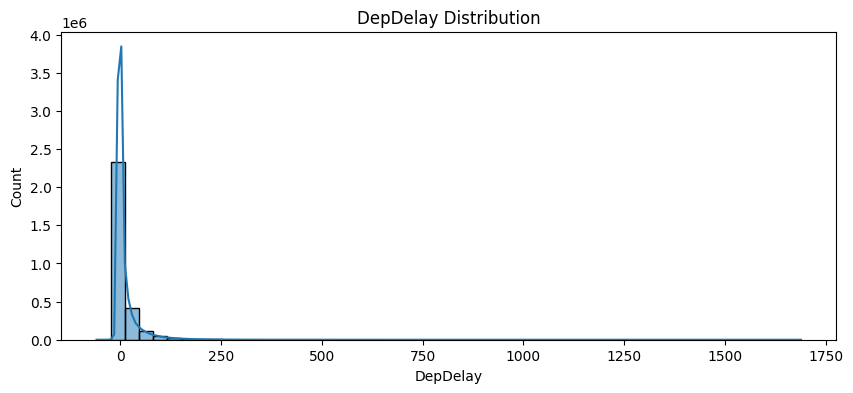

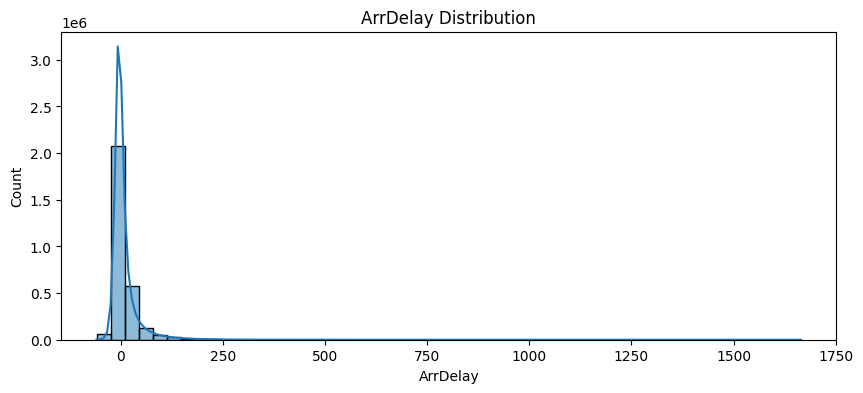

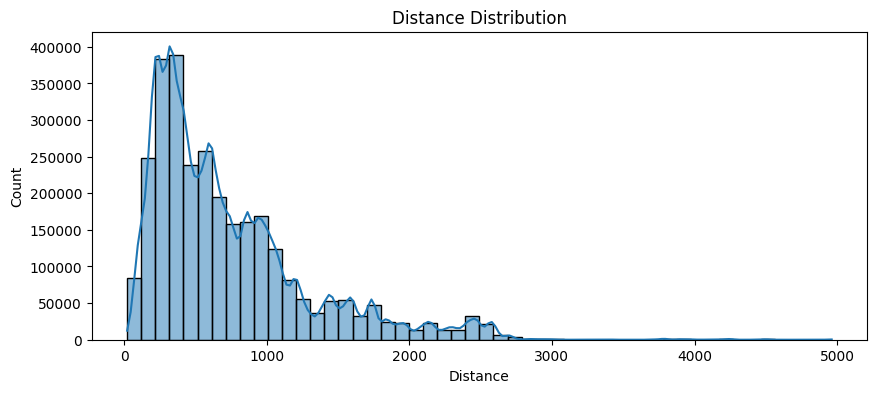

In [0]:
for col_name in ['DepDelay', 'ArrDelay', 'Distance']:
    plt.figure(figsize=(10,4))
    sns.histplot(pdf[col_name], bins=50, kde=True)
    plt.title(f"{col_name} Distribution")
    plt.show()


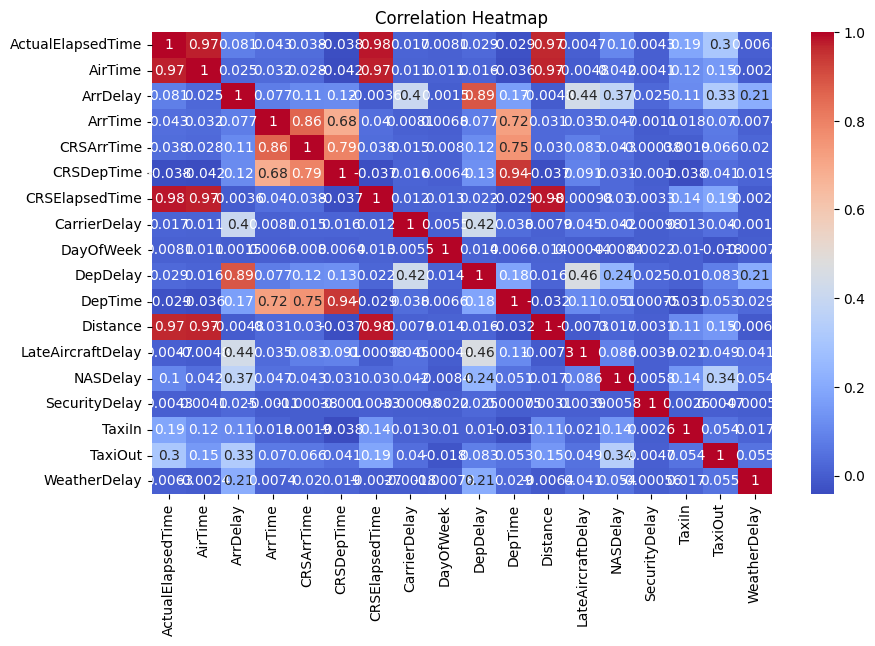

In [0]:
corr_matrix = pdf.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


###  Group Analysis

Delay by Day of Week

In [0]:
delay_by_day = flights_silver.groupBy("DayOfWeek") \
    .agg(round(avg("DepDelay"), 2).alias("AvgDepDelay")) \
    .orderBy("DayOfWeek")

display(delay_by_day)


DayOfWeek,AvgDepDelay
1,8.64
2,7.23
3,7.98
4,9.84
5,11.01
6,7.4
7,9.33


Delay by Airline (Carrier)

In [0]:
delay_by_carrier = flights_silver.groupBy("UniqueCarrier") \
    .agg(round(avg("DepDelay"), 2).alias("AvgDepDelay")) \
    .orderBy(desc("AvgDepDelay"))

display(delay_by_carrier)


UniqueCarrier,AvgDepDelay
EV,12.9
YV,12.58
B6,11.27
UA,10.69
FL,10.18
DH,9.76
WN,9.61
AS,9.41
HP,9.36
MQ,9.25


Delay vs Flight Distance

In [0]:
flights_silver = flights_silver.withColumn("DistanceBin",
    when(col("Distance") < 300, "Short")
    .when(col("Distance") < 1500, "Medium")
    .otherwise("Long")
)

delay_distance_cat = flights_silver.groupBy("DistanceBin") \
    .agg(round(avg("DepDelay"),2).alias("AvgDepDelay"))

display(delay_distance_cat)


DistanceBin,AvgDepDelay
Medium,9.03
Long,9.48
Short,7.73


### Time-Based Trend Analysis

Delay by Hour of Day

In [0]:
flights_silver = flights_silver.withColumn("DepHour", floor(col("CRSDepTime") / 100))

delay_by_hour = flights_silver.groupBy("DepHour") \
    .agg(round(avg("DepDelay"), 2).alias("AvgDepDelay")) \
    .orderBy("DepHour")

display(delay_by_hour)


DepHour,AvgDepDelay
0,9.1
1,5.09
2,2.01
3,8.34
4,7.82
5,1.28
6,1.64
7,2.71
8,4.05
9,4.98


## Final Curate/Clean

In [0]:
# Curate: Filter invalids/outliers, dedup
flights_curated = flights_silver.filter(
    col("DepDelay").isNotNull() &
    col("ArrDelay").isNotNull() &
    col("Distance").isNotNull() &
    (col("Distance") > 0) &
    (col("DayOfWeek").between(1, 7)) &
    (col("Cancelled") == 0) &
    (col("Diverted") == 0) &
    (col("DepDelay") < 500)  # Cap extreme delays
).dropDuplicates(["FlightNum", "Year", "Month", "DayofMonth", "Origin", "Dest"])

# Cast any remaining types
flights_curated = flights_curated.withColumn("DepDelay", col("DepDelay").cast(DoubleType())) \
    .withColumn("ArrDelay", col("ArrDelay").cast(DoubleType())) \
    .withColumn("Distance", col("Distance").cast(DoubleType())) \
    .withColumn("DayOfWeek", col("DayOfWeek").cast(IntegerType())) \
    .withColumn("Month", col("Month").cast(IntegerType())) \
    .withColumn("DayofMonth", col("DayofMonth").cast(IntegerType())) \
    .withColumn("Year", col("Year").cast(IntegerType()))

print(f"Curated rows: {flights_curated.count()}")

Curated rows: 2945866


## Feature Engineering (Derive New Features for Delay Prediction)

### 1: Derive FL_DATE

In [0]:
# Derive FL_DATE (full date for time-based analysis)
flights_features = flights_curated.withColumn(
    "FL_DATE",
    to_date(concat(
        col("Year").cast("string"), lit("-"),
        lpad(col("Month"), 2, "0"), lit("-"),
        lpad(col("DayofMonth"), 2, "0")
    ))
)

flights_features.select("Year", "Month", "DayofMonth", "FL_DATE").show(5, truncate=False)

+----+-----+----------+----------+
|Year|Month|DayofMonth|FL_DATE   |
+----+-----+----------+----------+
|1996|3    |14        |1996-03-14|
|2007|6    |4         |2007-06-04|
|2001|4    |6         |2001-04-06|
|2001|5    |24        |2001-05-24|
|1996|7    |24        |1996-07-24|
+----+-----+----------+----------+
only showing top 5 rows


### 2: Derive DepHour

In [0]:
# Derive DepHour (from CRSDepTime for scheduling insights)
flights_features = flights_features.withColumn(
    "DepHour",
    floor(col("CRSDepTime") / 100).cast(IntegerType())
).filter(col("DepHour").between(0, 23))

flights_features.select("CRSDepTime", "DepHour").show(10, truncate=False)


+----------+-------+
|CRSDepTime|DepHour|
+----------+-------+
|1720      |17     |
|735       |7      |
|919       |9      |
|1051      |10     |
|1740      |17     |
|1733      |17     |
|1717      |17     |
|830       |8      |
|1300      |13     |
|1047      |10     |
+----------+-------+
only showing top 10 rows


### 3: Derive DelayCategory

In [0]:
# DelayCategory (categorized for classification if needed, insights on minor/major delays)
flights_features = flights_features.withColumn(
    "DelayCategory",
    when(col("DepDelay") <= 0,  "OnTime")
    .when(col("DepDelay") <= 15, "Minor")
    .otherwise("Major")
)

flights_features.select("DepDelay", "DelayCategory").show(10, truncate=False)

+--------+-------------+
|DepDelay|DelayCategory|
+--------+-------------+
|3.0     |Minor        |
|-11.0   |OnTime       |
|-5.0    |OnTime       |
|6.0     |Minor        |
|6.0     |Minor        |
|-8.0    |OnTime       |
|11.0    |Minor        |
|2.0     |Minor        |
|-2.0    |OnTime       |
|0.0     |OnTime       |
+--------+-------------+
only showing top 10 rows


### 4: Compute Aggregates and Join

In [0]:
# Aggregates: Avg delays per carrier/origin (enrich each row with group avgs for ML)
# Average departure delay per carrier
avg_delay_carrier = flights_features.groupBy("UniqueCarrier") \
    .agg(round(avg("DepDelay"), 2).alias("AvgDepDelayCarrier"))

# Average departure delay per origin airport
avg_delay_origin = flights_features.groupBy("Origin") \
    .agg(round(avg("DepDelay"), 2).alias("AvgDepDelayOrigin"))

# Join back to enrich each row
flights_features = flights_features \
    .join(avg_delay_carrier, on="UniqueCarrier", how="left") \
    .join(avg_delay_origin, on="Origin",       how="left")

flights_features.select("UniqueCarrier", "AvgDepDelayCarrier", "Origin", "AvgDepDelayOrigin") \
                .show(10, truncate=False)


+-------------+------------------+------+-----------------+
|UniqueCarrier|AvgDepDelayCarrier|Origin|AvgDepDelayOrigin|
+-------------+------------------+------+-----------------+
|CO           |7.72              |EWR   |11.56            |
|FL           |10.11             |BWI   |9.13             |
|NW           |6.47              |JAX   |6.96             |
|DL           |7.66              |ATL   |11.26            |
|AA           |8.57              |BWI   |9.13             |
|MQ           |9.09              |BTR   |8.24             |
|CO           |7.72              |EWR   |11.56            |
|WN           |9.6               |HOU   |10.38            |
|DL           |7.66              |GTF   |-0.33            |
|AA           |8.57              |MIA   |10.34            |
+-------------+------------------+------+-----------------+
only showing top 10 rows


### 5: Select Curated Features, Show, and Count

In [0]:
gold_df = flights_features.select(
    "Year", "Month", "DayofMonth", "DayOfWeek",
    "FL_DATE",
    "DepDelay", "ArrDelay", "DepHour",
    "Distance",
    "Origin", "Dest",
    "UniqueCarrier",
    "DelayCategory",
    "AvgDepDelayCarrier",
    "AvgDepDelayOrigin"
)

gold_df.show(5, truncate=False)
print("Gold rows (before save):", gold_df.count())


+----+-----+----------+---------+----------+--------+--------+-------+--------+------+----+-------------+-------------+------------------+-----------------+
|Year|Month|DayofMonth|DayOfWeek|FL_DATE   |DepDelay|ArrDelay|DepHour|Distance|Origin|Dest|UniqueCarrier|DelayCategory|AvgDepDelayCarrier|AvgDepDelayOrigin|
+----+-----+----------+---------+----------+--------+--------+-------+--------+------+----+-------------+-------------+------------------+-----------------+
|2004|2    |22        |7        |2004-02-22|63.0    |51.0    |17     |628.0   |CHS   |EWR |XE           |Major        |8.53              |7.17             |
|2002|12   |14        |6        |2002-12-14|-2.0    |-19.0   |7      |1090.0  |MIA   |JFK |AA           |OnTime       |8.57              |10.34            |
|2004|3    |23        |2        |2004-03-23|-1.0    |2.0     |9      |288.0   |DTW   |GRB |NW           |OnTime       |6.47              |10.03            |
|2002|1    |17        |4        |2002-01-17|-3.0    |-15.0

##  Save to Gold 

In [0]:

gold_path = (
    "abfss://lakehouse@airlinedata60104384.dfs.core.windows.net/"
    "gold/flights/features_v1/"
)

# Save full engineered dataframe
gold_df.write.format("delta").mode("overwrite").save(gold_path)

# ====== Verify it's saved correctly ======
gold_df_verified = spark.read.format("delta").load(gold_path)

gold_df_verified.show(5, truncate=False)
print("Row count:", gold_df_verified.count())


+----+-----+----------+---------+----------+--------+--------+-------+--------+------+----+-------------+-------------+------------------+-----------------+
|Year|Month|DayofMonth|DayOfWeek|FL_DATE   |DepDelay|ArrDelay|DepHour|Distance|Origin|Dest|UniqueCarrier|DelayCategory|AvgDepDelayCarrier|AvgDepDelayOrigin|
+----+-----+----------+---------+----------+--------+--------+-------+--------+------+----+-------------+-------------+------------------+-----------------+
|1999|3    |1         |1        |1999-03-01|-2.0    |7.0     |7      |1310.0  |MCO   |MSP |NW           |OnTime       |6.47              |8.01             |
|1996|5    |12        |7        |1996-05-12|-1.0    |6.0     |17     |954.0   |IAD   |MSY |UA           |OnTime       |10.62             |10.3             |
|2000|11   |7         |2        |2000-11-07|-3.0    |33.0    |14     |224.0   |DFW   |IAH |AA           |OnTime       |8.57              |9.5              |
|1999|7    |15        |4        |1999-07-15|-1.0    |-2.0 